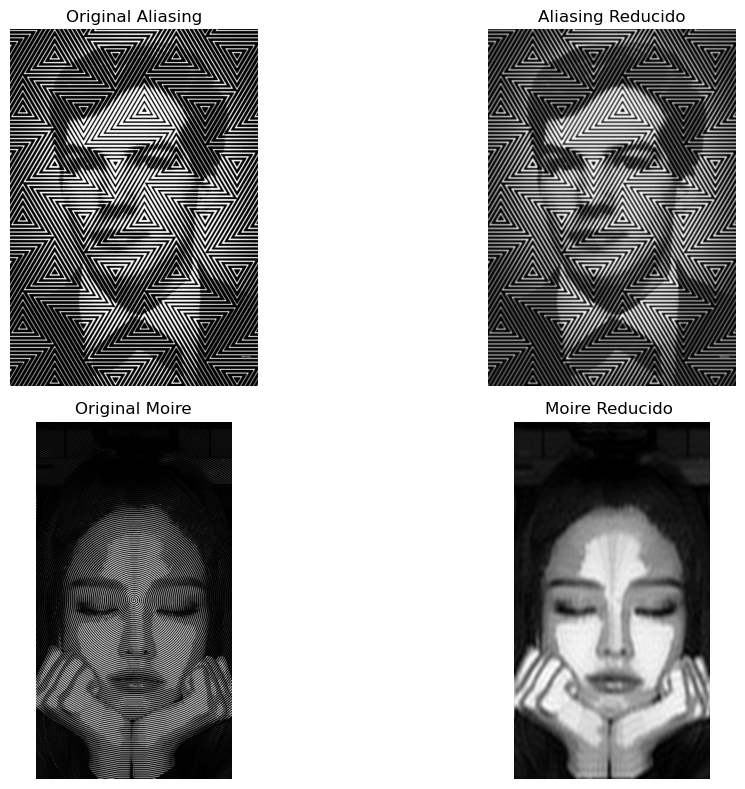

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. SUPER ANTI-ALIASING
# =========================
def fix_aliasing_pro(img):
    # 1. Blur más fuerte
    blur = cv2.GaussianBlur(img, (5, 5), 1.2)

    # 2. Downscale fuerte (elimina aliasing)
    small = cv2.resize(blur, None, fx=0.4, fy=0.4, interpolation=cv2.INTER_AREA)

    # 3. Upscale suave
    up = cv2.resize(small, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_CUBIC)

    # 4. Filtro bilateral (suaviza sin perder bordes)
    result = cv2.bilateralFilter(up, 9, 75, 75)

    return result


# =========================
# 2. SUPER ANTI-MOIRE
# =========================
def fix_moire_pro(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # FFT
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)

    rows, cols = gray.shape
    crow, ccol = rows//2, cols//2

    # Crear máscara (más agresiva)
    mask = np.ones((rows, cols), np.uint8)

    # eliminar frecuencias altas (zona circular)
    r = 40  # cuanto más grande, más elimina moire (pero más borroso)
    for i in range(rows):
        for j in range(cols):
            if (i - crow)**2 + (j - ccol)**2 > r*r:
                mask[i, j] = 0

    # aplicar filtro
    fshift_filtered = fshift * mask

    # reconstrucción
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)

    # suavizado final
    img_back = cv2.bilateralFilter(img_back.astype(np.uint8), 7, 50, 50)

    return img_back


# =========================
# CARGAR
# =========================
img_aliasing = cv2.imread("chico.jpg")
img_moire = cv2.imread("chica.jpg")

# originales
img_aliasing_rgb = cv2.cvtColor(img_aliasing, cv2.COLOR_BGR2RGB)
img_moire_gray = cv2.cvtColor(img_moire, cv2.COLOR_BGR2GRAY)

# procesar PRO
aliasing_fixed = fix_aliasing_pro(img_aliasing)
moire_fixed = fix_moire_pro(img_moire)

aliasing_fixed_rgb = cv2.cvtColor(aliasing_fixed, cv2.COLOR_BGR2RGB)

# =========================
# MOSTRAR
# =========================
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.title("Original Aliasing")
plt.imshow(img_aliasing_rgb)
plt.axis("off")

plt.subplot(2,2,2)
plt.title("Aliasing Reducido")
plt.imshow(aliasing_fixed_rgb)
plt.axis("off")

plt.subplot(2,2,3)
plt.title("Original Moire")
plt.imshow(img_moire_gray, cmap='gray')
plt.axis("off")

plt.subplot(2,2,4)
plt.title("Moire Reducido ")
plt.imshow(moire_fixed, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()